In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [ ]:
sns.set(style="whitegrid")
df = sns.load_dataset("tips")



In [ ]:
print("Initial Dataset Shape:", df.shape)
print(df.head())



Initial Dataset Shape: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
print("\nNull values before cleaning:")
print(df.isnull().sum())




Null values before cleaning:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [ ]:
print("\n--- STATISTICS ---")
print("Mean Total Bill:", df['total_bill'].mean())
print("Median Total Bill:", df['total_bill'].median())
print("Mode Total Bill:", df['total_bill'].mode()[0])




--- STATISTICS ---
Mean Total Bill: 19.78594262295082
Median Total Bill: 17.795
Mode Total Bill: 13.42


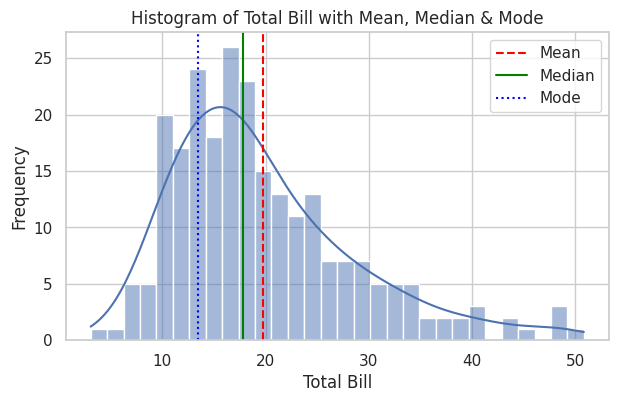

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(df['total_bill'], bins=30, kde=True)

plt.axvline(df['total_bill'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['total_bill'].median(), color='green', linestyle='-', label='Median')
plt.axvline(df['total_bill'].mode()[0], color='blue', linestyle=':', label='Mode')

plt.title("Histogram of Total Bill with Mean, Median & Mode")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.legend()
plt.show()



Skewness of Total Bill: 1.1332130376158205


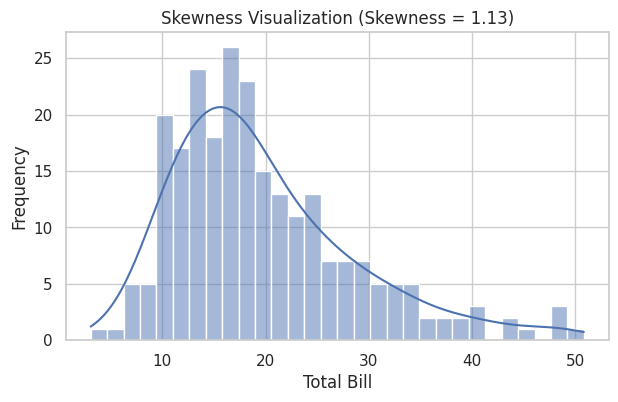

In [ ]:
skewness = df['total_bill'].skew()
print("Skewness of Total Bill:", skewness)

plt.figure(figsize=(7, 4))
sns.histplot(df['total_bill'], bins=30, kde=True)

plt.title(f"Skewness Visualization (Skewness = {skewness:.2f})")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()



In [ ]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nIQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]
print("Number of Outliers:", len(outliers))




IQR: 10.779999999999998
Lower Bound: -2.8224999999999945
Upper Bound: 40.29749999999999
Number of Outliers: 9


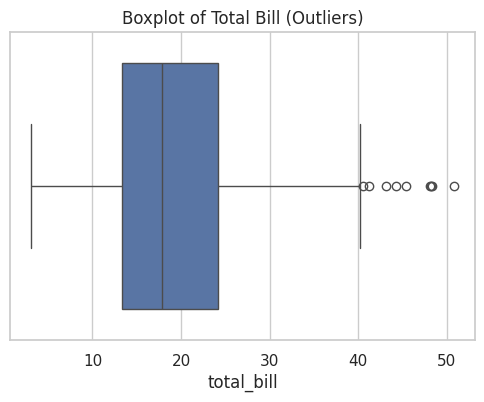

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['total_bill'])
plt.title("Boxplot of Total Bill (Outliers)")
plt.show()



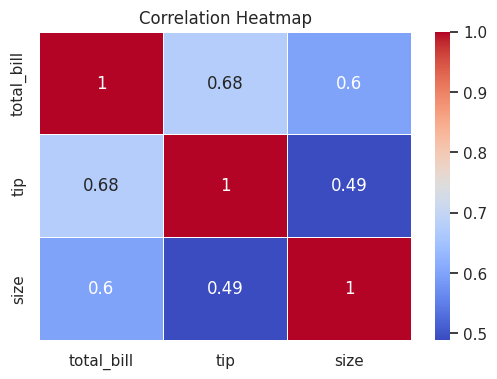

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['total_bill', 'tip', 'size']].corr(),
            annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()



In [ ]:
X = df[['total_bill']]
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



In [ ]:
print("\n--- LINEAR REGRESSION RESULTS ---")
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))




--- LINEAR REGRESSION RESULTS ---
Slope (Coefficient): 0.10696370685268658
Intercept: 0.925235558557056
Mean Squared Error: 0.5688142529229536
R² Score: 0.5449381659234664


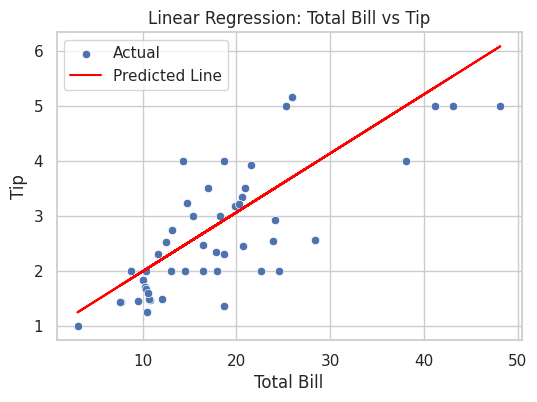

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_test['total_bill'], y=y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted Line")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Linear Regression: Total Bill vs Tip")
plt.legend()
plt.show()



In [ ]:
bill_amount = float(input("Enter total bill amount: "))

predicted_tip = model.predict([[bill_amount]])

print(f"\nFor a total bill of ₹{bill_amount:.2f},")
print(f"Predicted tip is ₹{predicted_tip[0]:.2f}")
